<a href="https://colab.research.google.com/github/subod4/ADdetection/blob/main/alzheimer_complete_pipeline_TEXT_FInal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Alzheimer's Disease Classification - Complete Self-Contained Pipeline

This notebook contains ALL necessary code embedded directly - **no external files required!**

## 📊 Project Overview

- **Goal**: Classify Alzheimer's Disease vs. Healthy Controls using speech analysis
- **Dataset**: DementiaBank Pitt Corpus (CHAT format transcripts)
- **Features**: 50+ linguistic markers including disfluencies, complexity, narrative coherence
- **Model**: XGBoost Classifier with GroupKFold Cross-Validation  
- **Target Performance**: 85%+ accuracy, 0.87+ AUC-ROC

## 📋 Sections

1. Setup & Installation
2. Core Classes (CHAFileParser, FeatureExtractor, AlzheimerClassifier)
3. Exploratory Data Analysis
4. Model Training
5. Model Evaluation
6. Inference

In [2]:
!unrar x /content/Control.rar Control
!unrar x /content/Dementia.rar Dementia


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/Control.rar

Creating    Control/Control                                           OK
Creating    Control/Control/cookie                                    OK
Extracting  Control/Control/cookie/002-0.cha                               0%  OK 
Extracting  Control/Control/cookie/002-1.cha                               0%  OK 
Extracting  Control/Control/cookie/002-2.cha                               1%  OK 
Extracting  Control/Control/cookie/002-3.cha                               1%  OK 
Extracting  Control/Control/cookie/006-2.cha                               2%  OK 
Extracting  Control/Control/cookie/006-3.cha                               2%  OK 
Extracting  Control/Control/cookie/006-4.cha                               3%  OK 
Extracting  Control/Control/cookie/013-0.cha                               3%  OK 
Extr

---
## 1. Setup & Installation

In [3]:
# Install required packages
!pip install -q numpy pandas scikit-learn xgboost matplotlib seaborn nltk tqdm scipy

In [4]:
# Import all required libraries
import os
import re
import glob
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix,
    precision_recall_fscore_support
)
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.tag import pos_tag
from scipy import stats

# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [5]:
# Download NLTK data
print("Downloading NLTK data...")
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
print("✓ NLTK data ready")

✓ NLTK data ready


In [6]:
# Setup paths
BASE_DIR = Path.cwd()
CONTROL_DIR = BASE_DIR / 'Control'
DEMENTIA_DIR = BASE_DIR / 'Dementia'
OUTPUT_DIR = BASE_DIR / 'results'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Working directory: {BASE_DIR}")
print(f"Control data: {CONTROL_DIR}")
print(f"Dementia data: {DEMENTIA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")

Working directory: /content
Control data: /content/Control
Dementia data: /content/Dementia
Output directory: /content/results


---
## 2. Core Classes - All Code Embedded

No external imports needed - everything is self-contained!

In [7]:
"""
Alzheimer's Disease Classification using DementiaBank Pitt Corpus
Author: GitHub Copilot
Date: January 2026

This script implements a comprehensive ML pipeline for classifying Alzheimer's disease
vs healthy controls using linguistic features from CHAT transcripts.
"""

import os
import re
import glob
import numpy as np
import pandas as pd
from pathlib import Path
from typing import List, Dict, Tuple, Optional
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, confusion_matrix,
                             precision_recall_fscore_support)
import xgboost as xgb

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP and linguistic analysis
try:
    import nltk
    from nltk.tokenize import word_tokenize, sent_tokenize
    from nltk.tag import pos_tag
    nltk.download('punkt', quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)
    nltk.download('punkt_tab', quiet=True)
    nltk.download('averaged_perceptron_tagger_eng', quiet=True)
except:
    print("Warning: NLTK not fully configured. Some features may not work.")


class CHAFileParser:
    """Parser for CHAT format files from DementiaBank"""

    def __init__(self, standardize_markers: bool = True):
        self.standardize_markers = standardize_markers

    def parse_file(self, filepath: str) -> Dict:
        """
        Parse a single CHA file and extract relevant information

        Args:
            filepath: Path to .cha file

        Returns:
            Dictionary with metadata and utterances
        """
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                content = f.read()
        except UnicodeDecodeError:
            # Try with different encoding
            with open(filepath, 'r', encoding='latin-1') as f:
                content = f.read()

        # Extract metadata
        metadata = self._extract_metadata(content)

        # Extract participant utterances only
        par_utterances = self._extract_participant_utterances(content)

        # Get clean and annotated versions
        clean_text = self._clean_utterances(par_utterances)
        annotated_text = self._standardize_annotations(par_utterances)

        return {
            'filepath': filepath,
            'subject_id': metadata.get('subject_id', ''),
            'diagnosis': metadata.get('diagnosis', ''),
            'age': metadata.get('age', ''),
            'gender': metadata.get('gender', ''),
            'task': metadata.get('task', ''),
            'raw_utterances': par_utterances,
            'clean_text': clean_text,
            'annotated_text': annotated_text,
            'utterance_count': len(par_utterances)
        }

    def _extract_metadata(self, content: str) -> Dict:
        """Extract metadata from CHA file header"""
        metadata = {}

        # Extract participant info from @ID line
        # Format: @ID: eng|Pitt|PAR|age;|gender|diagnosis||Participant|score||
        id_pattern = r'@ID:.*\|PAR\|([^|]*)\|([^|]*)\|([^|]*)\|'
        id_match = re.search(id_pattern, content)
        if id_match:
            age_str = id_match.group(1).strip()
            metadata['age'] = age_str.rstrip(';') if age_str else ''
            metadata['gender'] = id_match.group(2).strip()
            metadata['diagnosis'] = id_match.group(3).strip()

        # Extract task type from @G: line
        task_pattern = r'@G:\s*(\w+)'
        task_match = re.search(task_pattern, content)
        if task_match:
            metadata['task'] = task_match.group(1).strip()

        # Extract PID for subject ID
        pid_pattern = r'@PID:\s*(.+)'
        pid_match = re.search(pid_pattern, content)
        if pid_match:
            metadata['subject_id'] = pid_match.group(1).strip()

        return metadata

    def _extract_participant_utterances(self, content: str) -> List[str]:
        """Extract only PAR (participant) utterances, excluding INV (investigator)"""
        utterances = []

        # Match lines starting with *PAR:
        par_pattern = r'\*PAR:\s*(.+?)(?=\n[%*@]|\Z)'
        matches = re.findall(par_pattern, content, re.DOTALL)

        for match in matches:
            # Remove timing information (numbers at the end)
            utterance = re.sub(r'\s+\d+_\d+\s*$', '', match.strip())
            if utterance:
                utterances.append(utterance)

        return utterances

    def _standardize_annotations(self, utterances: List[str]) -> str:
        """Standardize clinical markers in utterances"""
        text = ' '.join(utterances)

        # Standardize fillers
        text = re.sub(r'&-um|&\+um', '[FILLER_UM]', text)
        text = re.sub(r'&-uh|&\+uh', '[FILLER_UH]', text)

        # Keep repair markers [//] and [/]
        # Keep error markers [* and variations
        # Keep grammatical markers [+ gram], [+ exc], etc.

        return text

    def _clean_utterances(self, utterances: List[str]) -> str:
        """Clean utterances for semantic analysis (remove all annotations)"""
        text = ' '.join(utterances)

        # Remove all CHAT annotations
        # Remove fillers (&-um, &+uh, etc.)
        text = re.sub(r'&[-+]\w+', '', text)

        # Remove all bracketed annotations [//], [/], [* xxx], [+ xxx], etc.
        text = re.sub(r'\[[\^/\*\+][^\]]*\]', '', text)
        text = re.sub(r'\[[^\]]*\]', '', text)

        # Remove angle brackets <...>
        text = re.sub(r'<[^>]*>', '', text)

        # Remove repetition markers (e.g., &=laughs)
        text = re.sub(r'&=[^\s]+', '', text)

        # Remove partial word markers and parentheses from word fragments
        text = re.sub(r'\(([^)]+)\)', r'\1', text)  # tryin(g) -> trying

        # Clean up multiple spaces and special characters
        text = re.sub(r'\s+', ' ', text).strip()
        text = re.sub(r'[▶]', '', text)

        return text


class FeatureExtractor:
    """Extract comprehensive linguistic features from transcripts"""

    def __init__(self):
        # Cookie Theft picture expected elements
        self.expected_elements = [
            'boy', 'cookie', 'jar', 'stool', 'fall', 'falling',
            'mother', 'woman', 'sink', 'water', 'overflow', 'dish',
            'window', 'curtain', 'girl', 'sister', 'daughter'
        ]

    def extract_all_features(self, parsed_data: Dict) -> Dict:
        """Extract all feature categories"""
        clean_text = parsed_data['clean_text']
        annotated_text = parsed_data['annotated_text']
        raw_utterances = parsed_data['raw_utterances']

        features = {}

        # Basic statistics
        features.update(self._extract_basic_stats(clean_text, raw_utterances))

        # Disfluency features (from annotated text)
        features.update(self._extract_disfluency_features(annotated_text, raw_utterances))

        # Linguistic complexity features
        features.update(self._extract_complexity_features(clean_text))

        # Narrative features (Cookie Theft specific)
        features.update(self._extract_narrative_features(clean_text))

        # Error features
        features.update(self._extract_error_features(raw_utterances))

        # POS-based features
        features.update(self._extract_pos_features(clean_text))

        return features

    def _extract_basic_stats(self, clean_text: str, utterances: List[str]) -> Dict:
        """Extract basic statistical features"""
        words = clean_text.split()
        word_count = len(words)

        features = {
            'word_count': word_count,
            'utterance_count': len(utterances),
            'avg_utterance_length': word_count / max(len(utterances), 1),
            'total_chars': len(clean_text),
            'avg_word_length': np.mean([len(w) for w in words]) if words else 0
        }

        return features

    def _extract_disfluency_features(self, annotated_text: str, raw_utterances: List[str]) -> Dict:
        """Extract disfluency markers - critical for AD detection"""

        # Count standardized fillers
        filler_um = len(re.findall(r'\[FILLER_UM\]', annotated_text))
        filler_uh = len(re.findall(r'\[FILLER_UH\]', annotated_text))

        # Count repair markers
        repairs = len(re.findall(r'\[//\]', annotated_text))
        retraces = len(re.findall(r'\[/\]', annotated_text))

        # Count false starts <...>
        false_starts = sum(text.count('<') for text in raw_utterances)

        # Count word repetitions (simple heuristic)
        words = annotated_text.lower().split()
        word_repetitions = 0
        for i in range(len(words) - 1):
            if words[i] == words[i+1] and len(words[i]) > 2:
                word_repetitions += 1

        word_count = len(annotated_text.split())

        features = {
            'filler_um_count': filler_um,
            'filler_uh_count': filler_uh,
            'total_fillers': filler_um + filler_uh,
            'fillers_per_100_words': (filler_um + filler_uh) / max(word_count, 1) * 100,
            'repair_count': repairs,
            'retrace_count': retraces,
            'false_start_count': false_starts,
            'word_repetition_count': word_repetitions,
            'total_disfluencies': filler_um + filler_uh + repairs + retraces + false_starts,
            'disfluency_rate': (filler_um + filler_uh + repairs + retraces) / max(word_count, 1) * 100
        }

        return features

    def _extract_complexity_features(self, clean_text: str) -> Dict:
        """Extract linguistic complexity measures"""
        words = clean_text.lower().split()
        word_count = len(words)

        if word_count == 0:
            return {
                'type_token_ratio': 0,
                'moving_avg_ttr': 0,
                'brunets_index': 0,
                'honores_statistic': 0,
                'unique_words': 0
            }

        # Type-Token Ratio (TTR)
        unique_words = len(set(words))
        ttr = unique_words / word_count

        # Moving-Average TTR (MATTR) - window of 50 words
        window_size = 50
        mattr_values = []
        if word_count >= window_size:
            for i in range(word_count - window_size + 1):
                window = words[i:i+window_size]
                mattr_values.append(len(set(window)) / window_size)
        mattr = np.mean(mattr_values) if mattr_values else ttr

        # Brunet's Index: W = N^(V^-0.165)
        # where N = total words, V = unique words
        brunets = word_count ** (unique_words ** -0.165) if unique_words > 0 else 0

        # Honoré's Statistic: (100 * log(N)) / (1 - (V1/V))
        # where V1 = number of words occurring once
        word_freq = Counter(words)
        v1 = sum(1 for freq in word_freq.values() if freq == 1)
        honores = (100 * np.log(word_count)) / max(1 - (v1 / max(unique_words, 1)), 0.01)

        features = {
            'type_token_ratio': ttr,
            'moving_avg_ttr': mattr,
            'brunets_index': brunets,
            'honores_statistic': honores,
            'unique_words': unique_words,
            'lexical_diversity': unique_words / max(word_count, 1)
        }

        return features

    def _extract_narrative_features(self, clean_text: str) -> Dict:
        """Extract Cookie Theft picture description narrative features"""
        text_lower = clean_text.lower()

        # Count expected story elements
        elements_mentioned = sum(1 for element in self.expected_elements
                                if element in text_lower)

        # Check for key events
        has_boy_stealing = any(word in text_lower for word in ['boy', 'child', 'kid']) and \
                          any(word in text_lower for word in ['cookie', 'jar'])
        has_falling = any(word in text_lower for word in ['fall', 'falling', 'tip'])
        has_water_overflow = any(word in text_lower for word in ['water', 'overflow', 'sink'])
        has_mother = any(word in text_lower for word in ['mother', 'woman', 'mom'])

        # Pronouns for referential cohesion
        pronouns = len(re.findall(r'\b(he|she|it|they|him|her|them|his|hers)\b', text_lower))

        # Spatial terms
        spatial_terms = len(re.findall(r'\b(on|in|under|over|above|below|up|down)\b', text_lower))

        features = {
            'elements_mentioned': elements_mentioned,
            'element_coverage': elements_mentioned / len(self.expected_elements),
            'has_boy_stealing': int(has_boy_stealing),
            'has_falling_event': int(has_falling),
            'has_water_overflow': int(has_water_overflow),
            'has_mother_figure': int(has_mother),
            'pronoun_count': pronouns,
            'spatial_term_count': spatial_terms,
            'narrative_completeness': (int(has_boy_stealing) + int(has_falling) +
                                      int(has_water_overflow) + int(has_mother)) / 4
        }

        return features

    def _extract_error_features(self, raw_utterances: List[str]) -> Dict:
        """Extract error markers from raw CHAT annotations"""
        raw_text = ' '.join(raw_utterances)

        # Grammatical errors [+ gram] or [* xxx]
        gram_errors = len(re.findall(r'\[\+\s*gram\]', raw_text))
        error_markers = len(re.findall(r'\[\*[^\]]*\]', raw_text))

        # Phonological errors [+ phon]
        phon_errors = len(re.findall(r'\[\+\s*phon\]', raw_text))

        # Incomplete words or fragments
        fragments = len(re.findall(r'\([^)]+\)', raw_text))

        features = {
            'grammatical_errors': gram_errors,
            'error_markers': error_markers,
            'phonological_errors': phon_errors,
            'word_fragments': fragments,
            'total_errors': gram_errors + error_markers + phon_errors
        }

        return features

    def _extract_pos_features(self, clean_text: str) -> Dict:
        """Extract Part-of-Speech based features"""
        try:
            words = word_tokenize(clean_text.lower())
            if not words:
                return self._empty_pos_features()

            pos_tags = pos_tag(words)
            pos_counts = Counter([tag for word, tag in pos_tags])

            # Count major categories
            nouns = sum(pos_counts[tag] for tag in pos_counts if tag.startswith('NN'))
            verbs = sum(pos_counts[tag] for tag in pos_counts if tag.startswith('VB'))
            adjectives = sum(pos_counts[tag] for tag in pos_counts if tag.startswith('JJ'))
            adverbs = sum(pos_counts[tag] for tag in pos_counts if tag.startswith('RB'))
            pronouns = sum(pos_counts[tag] for tag in pos_counts if tag.startswith('PRP'))

            total_words = len(words)

            features = {
                'noun_count': nouns,
                'verb_count': verbs,
                'adjective_count': adjectives,
                'adverb_count': adverbs,
                'pronoun_count_pos': pronouns,
                'noun_ratio': nouns / max(total_words, 1),
                'verb_ratio': verbs / max(total_words, 1),
                'noun_verb_ratio': nouns / max(verbs, 1),
                'pronoun_noun_ratio': pronouns / max(nouns, 1),
                'content_word_ratio': (nouns + verbs + adjectives) / max(total_words, 1)
            }

        except Exception as e:
            print(f"Warning: POS tagging failed: {e}")
            features = self._empty_pos_features()

        return features

    def _empty_pos_features(self) -> Dict:
        """Return empty POS features"""
        return {
            'noun_count': 0,
            'verb_count': 0,
            'adjective_count': 0,
            'adverb_count': 0,
            'pronoun_count_pos': 0,
            'noun_ratio': 0,
            'verb_ratio': 0,
            'noun_verb_ratio': 0,
            'pronoun_noun_ratio': 0,
            'content_word_ratio': 0
        }


class AlzheimerClassifier:
    """XGBoost classifier for Alzheimer's disease detection"""

    def __init__(self, n_estimators: int = 150, max_depth: int = 4,
                 learning_rate: float = 0.05, random_state: int = 42):
        """
        Initialize XGBoost classifier with parameters optimized for interpretability
        and small dataset performance
        """
        self.model = xgb.XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            reg_alpha=0.1,  # L1 regularization
            reg_lambda=1.0,  # L2 regularization
            scale_pos_weight=1,  # Will adjust based on class distribution
            objective='binary:logistic',
            eval_metric='auc',
            random_state=random_state,
            tree_method='hist',
            subsample=0.8,
            colsample_bytree=0.8
        )

        self.scaler = StandardScaler()
        self.feature_names = None
        self.feature_importance = None

    def train_with_cv(self, X: pd.DataFrame, y: np.ndarray, groups: np.ndarray,
                      n_splits: int = 5) -> Dict:
        """
        Train model with GroupKFold cross-validation to prevent data leakage

        Args:
            X: Feature matrix
            y: Target labels (0=Control, 1=Dementia)
            groups: Subject IDs for grouping
            n_splits: Number of CV folds

        Returns:
            Dictionary with cross-validation results
        """
        self.feature_names = X.columns.tolist()

        # Adjust scale_pos_weight for class imbalance
        pos_count = np.sum(y == 1)
        neg_count = np.sum(y == 0)
        self.model.scale_pos_weight = neg_count / max(pos_count, 1)

        # GroupKFold cross-validation
        gkf = GroupKFold(n_splits=n_splits)

        scoring = {
            'accuracy': 'accuracy',
            'auc': 'roc_auc',
            'f1': 'f1',
            'precision': 'precision',
            'recall': 'recall'
        }

        print(f"\nPerforming {n_splits}-fold GroupKFold cross-validation...")
        print(f"Total samples: {len(y)}, Controls: {neg_count}, Dementia: {pos_count}")
        print(f"Scale pos weight: {self.model.scale_pos_weight:.2f}\n")

        # Perform cross-validation
        cv_results = cross_validate(
            self.model, X, y,
            groups=groups,
            cv=gkf,
            scoring=scoring,
            return_train_score=True,
            n_jobs=-1
        )

        # Train final model on all data
        X_scaled = self.scaler.fit_transform(X)
        self.model.fit(X_scaled, y)

        # Get feature importance
        self.feature_importance = pd.DataFrame({
            'feature': self.feature_names,
            'importance': self.model.feature_importances_
        }).sort_values('importance', ascending=False)

        # Compile results
        results = {
            'cv_scores': cv_results,
            'mean_accuracy': np.mean(cv_results['test_accuracy']),
            'std_accuracy': np.std(cv_results['test_accuracy']),
            'mean_auc': np.mean(cv_results['test_auc']),
            'std_auc': np.std(cv_results['test_auc']),
            'mean_f1': np.mean(cv_results['test_f1']),
            'std_f1': np.std(cv_results['test_f1']),
            'mean_precision': np.mean(cv_results['test_precision']),
            'std_precision': np.std(cv_results['test_precision']),
            'mean_recall': np.mean(cv_results['test_recall']),
            'std_recall': np.std(cv_results['test_recall']),
        }

        return results

    def predict(self, X: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray]:
        """
        Make predictions on new data

        Returns:
            Tuple of (predictions, probabilities)
        """
        X_scaled = self.scaler.transform(X)
        predictions = self.model.predict(X_scaled)
        probabilities = self.model.predict_proba(X_scaled)[:, 1]
        return predictions, probabilities

    def get_feature_importance(self, top_n: int = 20) -> pd.DataFrame:
        """Get top N most important features"""
        if self.feature_importance is None:
            raise ValueError("Model must be trained first")
        return self.feature_importance.head(top_n)


def load_dataset(control_dir: str, dementia_dir: str,
                task: str = 'cookie') -> Tuple[pd.DataFrame, List[str]]:
    """
    Load and parse all CHA files from control and dementia directories

    Args:
        control_dir: Path to Control directory
        dementia_dir: Path to Dementia directory
        task: Task type to load ('cookie', 'fluency', 'recall', 'sentence')

    Returns:
        Tuple of (feature DataFrame, list of subject IDs for grouping)
    """
    parser = CHAFileParser()
    extractor = FeatureExtractor()

    all_data = []
    subject_ids = []

    # Load Control files
    control_files = glob.glob(os.path.join(control_dir, task, '*.cha'))
    print(f"Loading {len(control_files)} Control files from {task} task...")

    for filepath in control_files:
        try:
            parsed = parser.parse_file(filepath)
            features = extractor.extract_all_features(parsed)
            features['label'] = 0  # Control
            features['diagnosis'] = 'Control'
            features['file_id'] = Path(filepath).stem

            # Extract subject ID from filename (e.g., '002-0' -> '002')
            subject_id = Path(filepath).stem.split('-')[0]
            features['subject_id'] = subject_id
            subject_ids.append(subject_id)

            all_data.append(features)
        except Exception as e:
            print(f"Error parsing {filepath}: {e}")

    # Load Dementia files
    dementia_files = glob.glob(os.path.join(dementia_dir, task, '*.cha'))
    print(f"Loading {len(dementia_files)} Dementia files from {task} task...")

    for filepath in dementia_files:
        try:
            parsed = parser.parse_file(filepath)
            features = extractor.extract_all_features(parsed)
            features['label'] = 1  # Dementia
            features['diagnosis'] = parsed['diagnosis'] or 'Dementia'
            features['file_id'] = Path(filepath).stem

            # Extract subject ID from filename
            subject_id = Path(filepath).stem.split('-')[0]
            features['subject_id'] = subject_id
            subject_ids.append(subject_id)

            all_data.append(features)
        except Exception as e:
            print(f"Error parsing {filepath}: {e}")

    # Convert to DataFrame
    df = pd.DataFrame(all_data)

    print(f"\nDataset loaded successfully!")
    print(f"Total samples: {len(df)}")
    print(f"Controls: {len(df[df['label']==0])}")
    print(f"Dementia: {len(df[df['label']==1])}")
    print(f"Unique subjects: {df['subject_id'].nunique()}")

    return df, subject_ids


def plot_feature_importance(importance_df: pd.DataFrame, top_n: int = 20,
                           save_path: Optional[str] = None):
    """Plot feature importance"""
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(top_n)

    sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
    plt.title(f'Top {top_n} Most Important Features for AD Classification',
              fontsize=14, fontweight='bold')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Feature importance plot saved to {save_path}")

    plt.show()


def plot_cv_results(cv_results: Dict, save_path: Optional[str] = None):
    """Plot cross-validation results"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    metrics = ['accuracy', 'auc', 'f1', 'recall']
    titles = ['Accuracy', 'AUC-ROC', 'F1-Score', 'Sensitivity (Recall)']

    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx // 2, idx % 2]

        train_scores = cv_results['cv_scores'][f'train_{metric}']
        test_scores = cv_results['cv_scores'][f'test_{metric}']

        folds = range(1, len(train_scores) + 1)

        ax.plot(folds, train_scores, 'o-', label='Train', linewidth=2, markersize=8)
        ax.plot(folds, test_scores, 's-', label='Validation', linewidth=2, markersize=8)
        ax.axhline(y=np.mean(test_scores), color='r', linestyle='--',
                   label=f'Mean: {np.mean(test_scores):.3f}', linewidth=2)

        ax.set_xlabel('Fold', fontsize=11)
        ax.set_ylabel(title, fontsize=11)
        ax.set_title(f'{title} Across CV Folds', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(folds)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"CV results plot saved to {save_path}")

    plt.show()


def generate_classification_report(df: pd.DataFrame, predictions: np.ndarray,
                                   probabilities: np.ndarray, save_path: Optional[str] = None):
    """Generate comprehensive classification report"""
    y_true = df['label'].values

    # Calculate metrics
    accuracy = accuracy_score(y_true, predictions)
    auc = roc_auc_score(y_true, probabilities)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, predictions, average='binary')

    # Confusion matrix
    cm = confusion_matrix(y_true, predictions)
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp)
    sensitivity = recall  # Same as recall

    report = f"""
    ==========================================
    ALZHEIMER'S DISEASE CLASSIFICATION REPORT
    ==========================================

    Overall Performance Metrics:
    ---------------------------
    Accuracy:     {accuracy:.4f} ({accuracy*100:.2f}%)
    AUC-ROC:      {auc:.4f}
    F1-Score:     {f1:.4f}
    Precision:    {precision:.4f}
    Sensitivity:  {sensitivity:.4f} (Recall/True Positive Rate)
    Specificity:  {specificity:.4f} (True Negative Rate)

    Confusion Matrix:
    ----------------
                    Predicted
                Control  Dementia
    Actual  Control    {tn:4d}    {fp:4d}
            Dementia   {fn:4d}    {tp:4d}

    Clinical Interpretation:
    -----------------------
    True Positives (TP):  {tp} - Correctly identified AD patients
    True Negatives (TN):  {tn} - Correctly identified healthy controls
    False Positives (FP): {fp} - Healthy controls misclassified as AD
    False Negatives (FN): {fn} - AD patients misclassified as healthy

    Detailed Classification Report:
    ------------------------------
    """

    report += classification_report(y_true, predictions,
                                   target_names=['Control', 'Dementia'])

    print(report)

    if save_path:
        with open(save_path, 'w') as f:
            f.write(report)
        print(f"\nClassification report saved to {save_path}")

    return report




---
## 3. Exploratory Data Analysis

In [8]:
# Load the dataset
print("Loading dataset...")
print("This may take a few minutes as we parse all CHAT files...\n")

TASK = 'cookie'  # Options: 'cookie', 'fluency', 'recall', 'sentence'

df, subject_ids = load_dataset(
    str(CONTROL_DIR),
    str(DEMENTIA_DIR),
    task=TASK
)

print(f"\n✓ Dataset loaded successfully")
print(f"  Total samples: {len(df)}")
print(f"  Unique subjects: {df['subject_id'].nunique()}")
print(f"  Features: {len([c for c in df.columns if c not in ['label', 'diagnosis', 'file_id', 'subject_id']])}")

Loading dataset...
This may take a few minutes as we parse all CHAT files...

Loading 243 Control files from cookie task...
Loading 309 Dementia files from cookie task...

Dataset loaded successfully!
Total samples: 552
Controls: 243
Dementia: 309
Unique subjects: 292

✓ Dataset loaded successfully
  Total samples: 552
  Unique subjects: 292
  Features: 45


In [9]:
# Display sample data
print("First few rows of the dataset:\n")
display(df.head())

First few rows of the dataset:



,word_count,utterance_count,avg_utterance_length,total_chars,avg_word_length,filler_um_count,filler_uh_count,total_fillers,fillers_per_100_words,repair_count,...,pronoun_count_pos,noun_ratio,verb_ratio,noun_verb_ratio,pronoun_noun_ratio,content_word_ratio,label,diagnosis,file_id,subject_id
0,101,12,8.416667,580,4.752475,1,3,4,3.361345,1,...,9,0.228070,0.254386,0.896552,0.346154,0.491228,0,Control,137-2,137
1,89,8,11.125000,494,4.561798,0,0,0,0.000000,1,...,2,0.252632,0.168421,1.500000,0.083333,0.442105,0,Control,022-2,022
2,134,25,5.360000,779,4.820896,2,5,7,2.413793,6,...,9,0.200000,0.250000,0.800000,0.321429,0.514286,0,Control,015-0,015
3,49,7,7.000000,285,4.836735,0,2,2,3.773585,0,...,3,0.196078,0.333333,0.588235,0.300000,0.568627,0,Control,139-1,139
4,109,7,15.571429,577,4.302752,0,0,0,0.000000,1,...,7,0.201754,0.228070,0.884615,0.304348,0.473684,0,Control,318-1,318


In [10]:
# Basic statistics
print("="*70)
print("DATASET STATISTICS")
print("="*70)

print(f"\nTotal Samples: {len(df)}")
print(f"Unique Subjects: {df['subject_id'].nunique()}")

print(f"\nClass Distribution:")
print(df['diagnosis'].value_counts())

print(f"\nSamples per Subject:")
samples_per_subject = df.groupby('subject_id').size()
print(f"  Mean: {samples_per_subject.mean():.2f}")
print(f"  Median: {samples_per_subject.median():.0f}")
print(f"  Range: {samples_per_subject.min():.0f} - {samples_per_subject.max():.0f}")

DATASET STATISTICS

Total Samples: 552
Unique Subjects: 292

Class Distribution:
diagnosis
Control       243
ProbableAD    234
MCI            42
PossibleAD     21
Vascular        5
Memory          3
Dementia        3
Other           1
Name: count, dtype: int64

Samples per Subject:
  Mean: 1.89
  Median: 2
  Range: 1 - 5


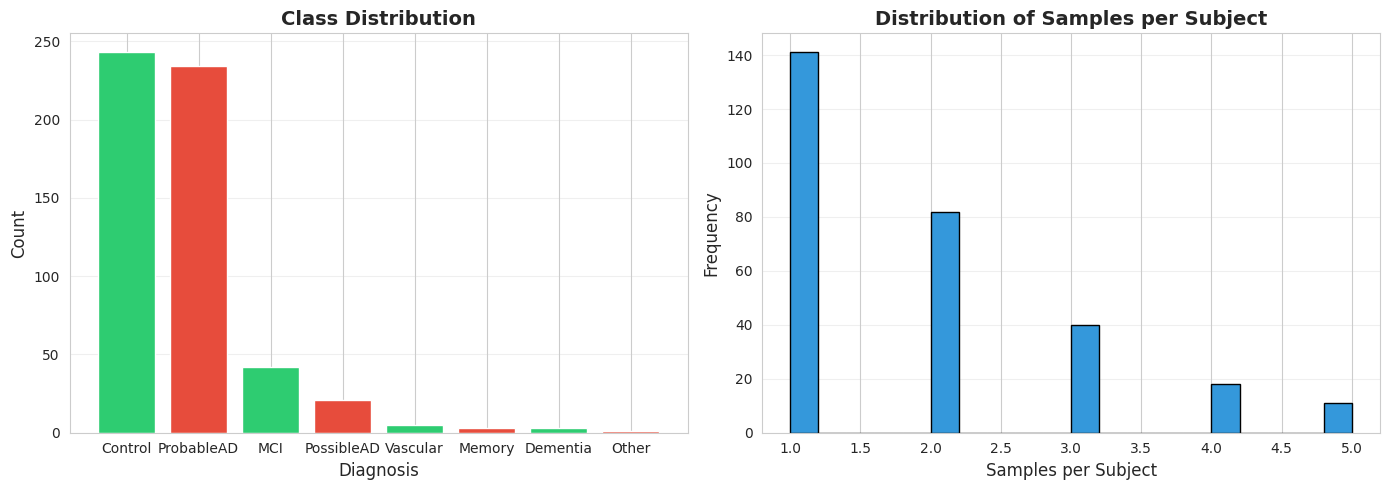

✓ Class distribution plot saved


In [11]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

diagnosis_counts = df['diagnosis'].value_counts()
axes[0].bar(diagnosis_counts.index, diagnosis_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_xlabel('Diagnosis', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(samples_per_subject, bins=20, color='#3498db', edgecolor='black')
axes[1].set_xlabel('Samples per Subject', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Samples per Subject', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Class distribution plot saved")

---
## 4. Model Training

In [12]:
# Prepare features and split by subjects
print("Preparing features with train-test split...\n")

exclude_cols = ['label', 'diagnosis', 'file_id', 'subject_id']
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Split subjects into train and test sets (80/20 split)
from sklearn.model_selection import train_test_split

unique_subjects = df['subject_id'].unique()
subject_labels = df.groupby('subject_id')['label'].first().to_dict()
y_subjects = np.array([subject_labels[s] for s in unique_subjects])

# Stratified split by subject to maintain class balance
train_subjects, test_subjects = train_test_split(
    unique_subjects,
    test_size=0.2,
    random_state=42,
    stratify=y_subjects
)

print(f"Total subjects: {len(unique_subjects)}")
print(f"Train subjects: {len(train_subjects)}")
print(f"Test subjects: {len(test_subjects)}")

# Create train and test DataFrames
train_df = df[df['subject_id'].isin(train_subjects)].copy()
test_df = df[df['subject_id'].isin(test_subjects)].copy()

print(f"\nTrain set: {len(train_df)} samples")
print(f"  Controls: {sum(train_df['label'] == 0)}")
print(f"  Dementia: {sum(train_df['label'] == 1)}")

print(f"\nTest set: {len(test_df)} samples")
print(f"  Controls: {sum(test_df['label'] == 0)}")
print(f"  Dementia: {sum(test_df['label'] == 1)}")

# Prepare training features
X_train = train_df[feature_cols]
y_train = train_df['label'].values
groups_train = train_df['subject_id'].values

# Prepare test features
X_test = test_df[feature_cols]
y_test = test_df['label'].values

# Handle NaN and inf
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f"\nFeature dimensions: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Preparing features with train-test split...

Total subjects: 292
Train subjects: 233
Test subjects: 59

Train set: 430 samples
  Controls: 196
  Dementia: 234

Test set: 122 samples
  Controls: 47
  Dementia: 75

Feature dimensions: 45
Training samples: 430
Test samples: 122


In [13]:
# Initialize and train classifier with ANTI-OVERFITTING settings
print("\n" + "="*70)
print("TRAINING XGBOOST CLASSIFIER (Regularized)")
print("="*70)

RANDOM_STATE = 42
N_SPLITS = 5

# Create a more regularized XGBoost model to prevent overfitting
from sklearn.feature_selection import SelectKBest, f_classif

# Step 1: Feature Selection - reduce features to top K most important
print("\nStep 1: Feature Selection")
k_features = min(20, X_train.shape[1])  # Use top 20 features
selector = SelectKBest(score_func=f_classif, k=k_features)
X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

# Get selected feature names
selected_mask = selector.get_support()
selected_features = [f for f, s in zip(feature_cols, selected_mask) if s]
print(f"Selected {len(selected_features)} features from {len(feature_cols)}")
print(f"Top features: {selected_features[:10]}...")

# Convert back to DataFrame for compatibility
X_train_sel = pd.DataFrame(X_train_selected, columns=selected_features)
X_test_sel = pd.DataFrame(X_test_selected, columns=selected_features)

# Step 2: Create heavily regularized classifier
print("\nStep 2: Training with strong regularization")

# Override the classifier with anti-overfitting parameters
classifier = AlzheimerClassifier(
    n_estimators=50,        # Reduced from 150
    max_depth=2,            # Reduced from 4 (shallower trees)
    learning_rate=0.01,     # Reduced from 0.05 (slower learning)
    random_state=RANDOM_STATE
)

# Manually set additional regularization parameters
classifier.model.set_params(
    reg_alpha=1.0,          # Increased L1 regularization (was 0.1)
    reg_lambda=5.0,         # Increased L2 regularization (was 1.0)
    subsample=0.6,          # Reduced from 0.8 (use less data per tree)
    colsample_bytree=0.6,   # Reduced from 0.8 (use fewer features per tree)
    min_child_weight=5,     # Require more samples per leaf
    gamma=1.0,              # Minimum loss reduction for split
)

print(f"\nTraining with {N_SPLITS}-fold GroupKFold cross-validation on TRAINING SET...")
print("Using regularized parameters to prevent overfitting...\n")

# Update feature_cols to use selected features
feature_cols_selected = selected_features

cv_results = classifier.train_with_cv(X_train_sel, y_train, groups_train, n_splits=N_SPLITS)

print("\n" + "="*70)
print("CROSS-VALIDATION RESULTS (Training Set)")
print("="*70)
print(f"Accuracy:  {cv_results['mean_accuracy']:.4f} ± {cv_results['std_accuracy']:.4f}")
print(f"AUC-ROC:   {cv_results['mean_auc']:.4f} ± {cv_results['std_auc']:.4f}")
print(f"F1-Score:  {cv_results['mean_f1']:.4f} ± {cv_results['std_f1']:.4f}")
print(f"Precision: {cv_results['mean_precision']:.4f} ± {cv_results['std_precision']:.4f}")
print(f"Recall:    {cv_results['mean_recall']:.4f} ± {cv_results['std_recall']:.4f}")


TRAINING XGBOOST CLASSIFIER (Regularized)

Step 1: Feature Selection
Selected 20 features from 45
Top features: ['avg_utterance_length', 'filler_um_count', 'repair_count', 'retrace_count', 'false_start_count', 'total_disfluencies', 'disfluency_rate', 'elements_mentioned', 'element_coverage', 'has_boy_stealing']...

Step 2: Training with strong regularization

Training with 5-fold GroupKFold cross-validation on TRAINING SET...
Using regularized parameters to prevent overfitting...


Performing 5-fold GroupKFold cross-validation...
Total samples: 430, Controls: 196, Dementia: 234
Scale pos weight: 0.84


CROSS-VALIDATION RESULTS (Training Set)
Accuracy:  0.7140 ± 0.0631
AUC-ROC:   0.8156 ± 0.0485
F1-Score:  0.7073 ± 0.0659
Precision: 0.7981 ± 0.0339
Recall:    0.6433 ± 0.1068


CV results plot saved to /content/results/cv_results.png


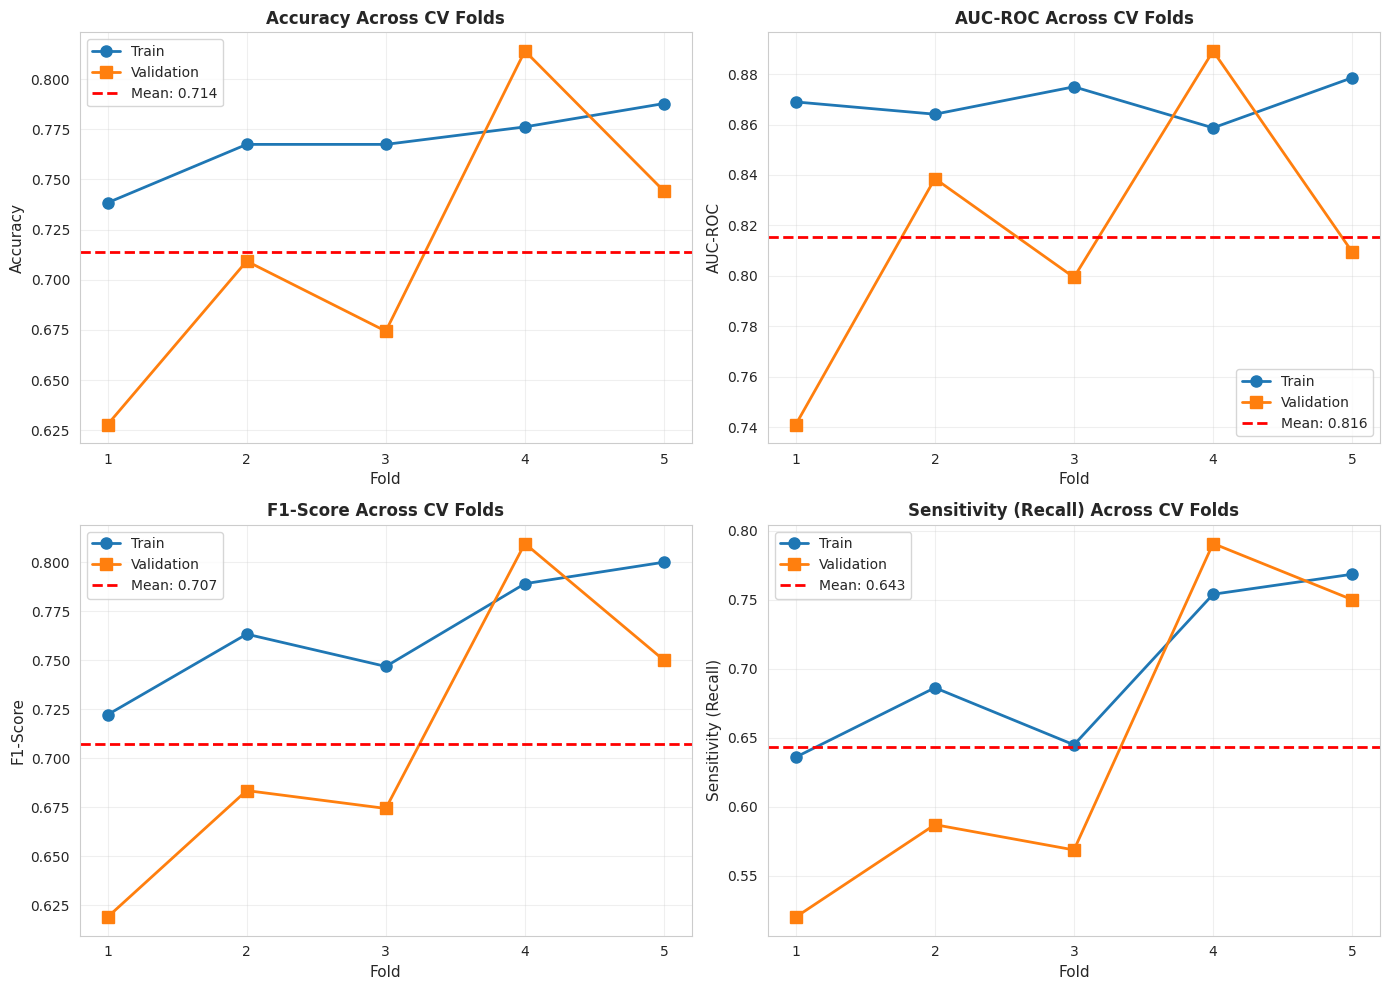

✓ Cross-validation results plot saved


In [14]:
# Visualize cross-validation results
plot_cv_results(cv_results, save_path=OUTPUT_DIR / 'cv_results.png')
plt.show()

print("✓ Cross-validation results plot saved")

---
## 5. Model Evaluation

In [15]:
# Feature importance analysis
print("\n" + "="*70)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*70)

feature_importance_df = classifier.get_feature_importance(top_n=20)
print("\nTop 20 Most Important Features:")
print(feature_importance_df.to_string(index=False))

feature_importance_df.to_csv(OUTPUT_DIR / 'feature_importance.csv', index=False)
print(f"\n✓ Feature importance saved to: {OUTPUT_DIR / 'feature_importance.csv'}")


FEATURE IMPORTANCE ANALYSIS

Top 20 Most Important Features:
               feature  importance
    elements_mentioned    0.208161
      element_coverage    0.201474
narrative_completeness    0.108971
    content_word_ratio    0.106193
        word_fragments    0.062027
            verb_ratio    0.050507
  avg_utterance_length    0.043141
          total_errors    0.041843
       disfluency_rate    0.041360
    pronoun_noun_ratio    0.035566
    total_disfluencies    0.035029
         retrace_count    0.028637
     false_start_count    0.019838
          repair_count    0.017253
       filler_um_count    0.000000
      has_boy_stealing    0.000000
    has_water_overflow    0.000000
     has_falling_event    0.000000
         error_markers    0.000000
     has_mother_figure    0.000000

✓ Feature importance saved to: /content/results/feature_importance.csv


Feature importance plot saved to /content/results/feature_importance.png


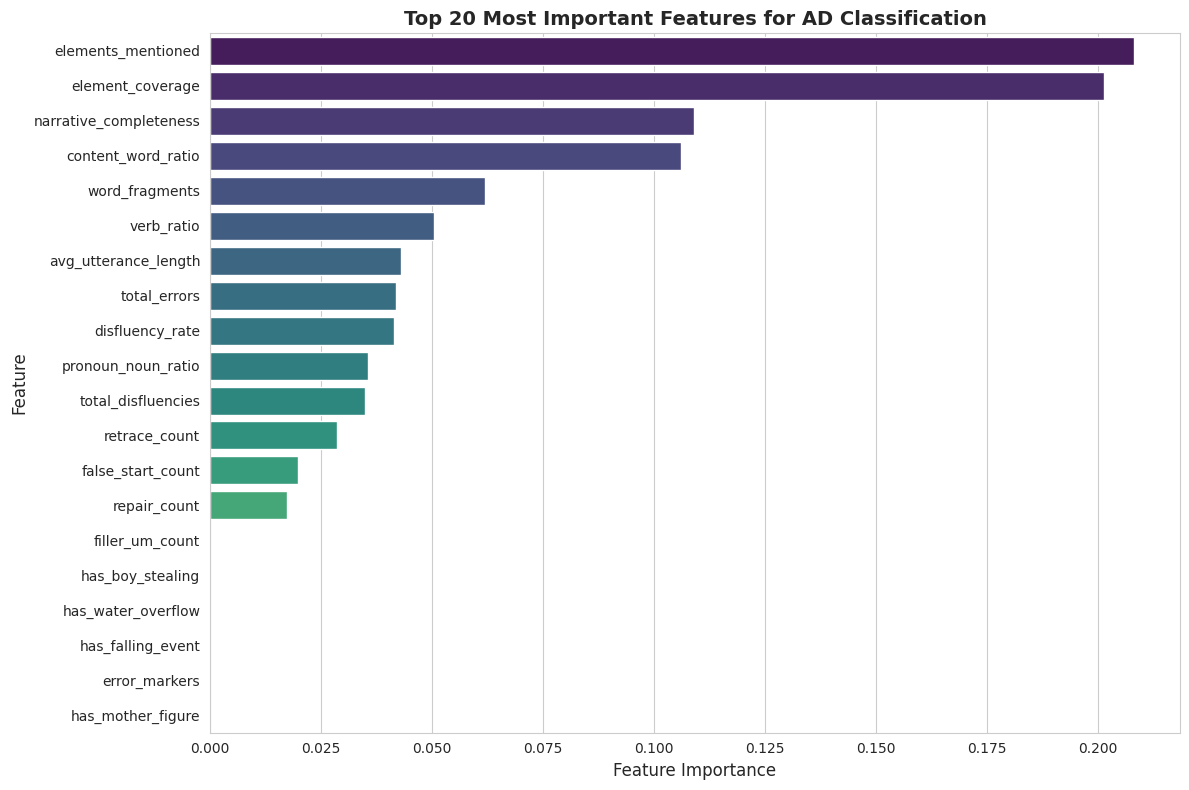

✓ Feature importance plot saved


In [16]:
# Plot feature importance
plot_feature_importance(
    classifier.feature_importance,
    top_n=20,
    save_path=OUTPUT_DIR / 'feature_importance.png'
)
plt.show()

print("✓ Feature importance plot saved")


TRAINING SET PERFORMANCE
✓ Training predictions saved to: /content/results/train_predictions.csv

    ALZHEIMER'S DISEASE CLASSIFICATION REPORT
    
    Overall Performance Metrics:
    ---------------------------
    Accuracy:     0.7860 (78.60%)
    AUC-ROC:      0.8679
    F1-Score:     0.7820
    Precision:    0.8777
    Sensitivity:  0.7051 (Recall/True Positive Rate)
    Specificity:  0.8827 (True Negative Rate)
    
    Confusion Matrix:
    ----------------
                    Predicted
                Control  Dementia
    Actual  Control     173      23
            Dementia     69     165
    
    Clinical Interpretation:
    -----------------------
    True Positives (TP):  165 - Correctly identified AD patients
    True Negatives (TN):  173 - Correctly identified healthy controls
    False Positives (FP): 23 - Healthy controls misclassified as AD
    False Negatives (FN): 69 - AD patients misclassified as healthy
    
    Detailed Classification Report:
    ---------------

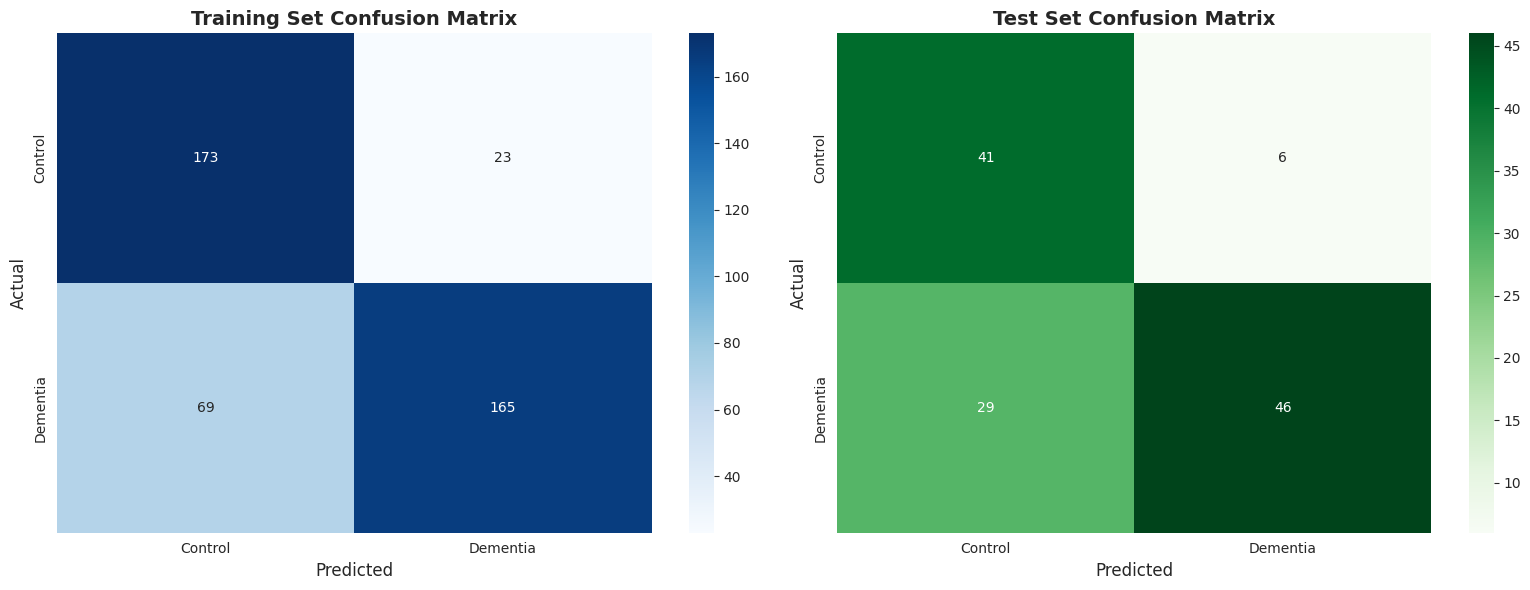


✓ Confusion matrices saved

TRAIN vs TEST COMPARISON

Accuracy:  Train=0.7860  |  Test=0.7131  |  Gap=0.0729
AUC-ROC:   Train=0.8679  |  Test=0.8318  |  Gap=0.0361
F1-Score:  Train=0.7820  |  Test=0.7244  |  Gap=0.0576

⚠️ Moderate overfitting. Consider more regularization.


In [17]:
# Evaluate on TRAINING SET (using selected features)
print("\n" + "="*70)
print("TRAINING SET PERFORMANCE")
print("="*70)

train_predictions, train_probabilities = classifier.predict(X_train_sel)

train_df['predicted_label'] = train_predictions
train_df['prediction_probability'] = train_probabilities

train_df.to_csv(OUTPUT_DIR / 'train_predictions.csv', index=False)
print(f"✓ Training predictions saved to: {OUTPUT_DIR / 'train_predictions.csv'}")

generate_classification_report(
    train_df,
    train_predictions,
    train_probabilities,
    save_path=OUTPUT_DIR / 'train_classification_report.txt'
)

# Evaluate on TEST SET (HELD-OUT DATA)
print("\n" + "="*70)
print("TEST SET PERFORMANCE (HELD-OUT DATA)")
print("="*70)

test_predictions, test_probabilities = classifier.predict(X_test_sel)

test_df['predicted_label'] = test_predictions
test_df['prediction_probability'] = test_probabilities

test_df.to_csv(OUTPUT_DIR / 'test_predictions.csv', index=False)
print(f"✓ Test predictions saved to: {OUTPUT_DIR / 'test_predictions.csv'}")

generate_classification_report(
    test_df,
    test_predictions,
    test_probabilities,
    save_path=OUTPUT_DIR / 'test_classification_report.txt'
)

# Display confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training confusion matrix
cm_train = confusion_matrix(y_train, train_predictions)
sns.heatmap(
    cm_train,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Control', 'Dementia'],
    yticklabels=['Control', 'Dementia'],
    ax=axes[0]
)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_title('Training Set Confusion Matrix', fontsize=14, fontweight='bold')

# Test confusion matrix
cm_test = confusion_matrix(y_test, test_predictions)
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Control', 'Dementia'],
    yticklabels=['Control', 'Dementia'],
    ax=axes[1]
)
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].set_title('Test Set Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Confusion matrices saved")

# Summary comparison
print("\n" + "="*70)
print("TRAIN vs TEST COMPARISON")
print("="*70)

train_acc = accuracy_score(y_train, train_predictions)
train_auc = roc_auc_score(y_train, train_probabilities)
train_f1 = f1_score(y_train, train_predictions)

test_acc = accuracy_score(y_test, test_predictions)
test_auc = roc_auc_score(y_test, test_probabilities)
test_f1 = f1_score(y_test, test_predictions)

print(f"\nAccuracy:  Train={train_acc:.4f}  |  Test={test_acc:.4f}  |  Gap={train_acc-test_acc:.4f}")
print(f"AUC-ROC:   Train={train_auc:.4f}  |  Test={test_auc:.4f}  |  Gap={train_auc-test_auc:.4f}")
print(f"F1-Score:  Train={train_f1:.4f}  |  Test={test_f1:.4f}  |  Gap={train_f1-test_f1:.4f}")

# Overfitting assessment
gap = train_acc - test_acc
if gap < 0.05:
    print("\n✅ Good generalization! Train-test gap is small.")
elif gap < 0.15:
    print("\n⚠️ Moderate overfitting. Consider more regularization.")
else:
    print("\n❌ Significant overfitting detected. Model may need further tuning.")

In [18]:
# Save trained model with selected features info
model_path = OUTPUT_DIR / 'trained_model.pkl'

save_data = {
    'classifier': classifier,
    'feature_columns': feature_cols_selected,  # Save selected features
    'selector': selector,  # Save the feature selector
    'original_feature_columns': feature_cols,
    'cv_results': cv_results,
    'training_info': {
        'n_train_samples': len(train_df),
        'n_test_samples': len(test_df),
        'n_train_subjects': len(train_subjects),
        'n_test_subjects': len(test_subjects),
        'n_original_features': len(feature_cols),
        'n_selected_features': len(feature_cols_selected),
        'task': TASK,
        'random_state': RANDOM_STATE,
        'cv_accuracy': cv_results['mean_accuracy'],
        'cv_auc_roc': cv_results['mean_auc'],
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'train_auc': train_auc,
        'test_auc': test_auc,
        'overfitting_gap': train_acc - test_acc
    }
}

with open(model_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f"✓ Model saved to: {model_path}")
print(f"\nModel info:")
for key, value in save_data['training_info'].items():
    print(f"  {key}: {value}")

✓ Model saved to: /content/results/trained_model.pkl

Model info:
  n_train_samples: 430
  n_test_samples: 122
  n_train_subjects: 233
  n_test_subjects: 59
  n_original_features: 45
  n_selected_features: 20
  task: cookie
  random_state: 42
  cv_accuracy: 0.713953488372093
  cv_auc_roc: 0.815558182425195
  train_accuracy: 0.786046511627907
  test_accuracy: 0.7131147540983607
  train_auc: 0.8678811268096982
  test_auc: 0.83177304964539
  overfitting_gap: 0.07293175752954628


---
## 6. Inference - Make Predictions on New Data

In [19]:
# Example: Predict on a single file (using selected features)
test_file = str(CONTROL_DIR / 'cookie' / '002-0.cha')

print(f"Making prediction on: {test_file}\n")

# Parse file
parser = CHAFileParser()
parsed_data = parser.parse_file(test_file)

# Extract features
extractor = FeatureExtractor()
features = extractor.extract_all_features(parsed_data)

# Create feature vector with ALL original features first
feature_vector = pd.DataFrame([features])[feature_cols]
feature_vector = feature_vector.replace([np.inf, -np.inf], np.nan).fillna(0)

# Apply feature selection
feature_vector_selected = selector.transform(feature_vector)
feature_vector_sel = pd.DataFrame(feature_vector_selected, columns=feature_cols_selected)

# Predict
prediction, probability = classifier.predict(feature_vector_sel)

print("="*70)
print("PREDICTION RESULTS")
print("="*70)
print(f"File: {Path(test_file).name}")
print(f"Predicted Class: {'Dementia' if prediction[0] == 1 else 'Control'}")
print(f"Confidence: {probability[0]:.2%}")
print(f"\nSubject ID: {parsed_data['subject_id']}")
print(f"Actual Diagnosis: {parsed_data['diagnosis']}")

Making prediction on: /content/Control/cookie/002-0.cha

PREDICTION RESULTS
File: 002-0.cha
Predicted Class: Control
Confidence: 41.12%

Subject ID: 11312/a-00090633-0
Actual Diagnosis: Control


In [20]:
# Batch prediction example (using selected features)
test_directory = DEMENTIA_DIR / 'cookie'
test_files = list(test_directory.glob('*.cha'))[:5]  # Test on first 5 files

print(f"\nBatch prediction on {len(test_files)} files from {test_directory.name}\n")

batch_results = []

for file_path in test_files:
    parsed_data = parser.parse_file(str(file_path))
    features = extractor.extract_all_features(parsed_data)

    # Create feature vector with all features, then select
    feature_vector = pd.DataFrame([features])[feature_cols]
    feature_vector = feature_vector.replace([np.inf, -np.inf], np.nan).fillna(0)
    feature_vector_selected = selector.transform(feature_vector)
    feature_vector_sel = pd.DataFrame(feature_vector_selected, columns=feature_cols_selected)

    prediction, probability = classifier.predict(feature_vector_sel)

    batch_results.append({
        'filename': file_path.name,
        'subject_id': parsed_data['subject_id'],
        'actual_diagnosis': parsed_data['diagnosis'],
        'predicted_class': 'Dementia' if prediction[0] == 1 else 'Control',
        'confidence': probability[0]
    })

batch_df = pd.DataFrame(batch_results)
print("Batch Prediction Results:")
display(batch_df)

correct = sum(batch_df['actual_diagnosis'].str.lower().str.contains('dementia') ==
              (batch_df['predicted_class'] == 'Dementia'))
print(f"\nBatch Accuracy: {correct}/{len(batch_df)} ({correct/len(batch_df):.2%})")


Batch prediction on 5 files from cookie

Batch Prediction Results:


,filename,subject_id,actual_diagnosis,predicted_class,confidence
0,674-0.cha,11312/a-00090615-0,ProbableAD,Dementia,0.614093
1,607-0.cha,11312/a-00090596-0,PossibleAD,Control,0.448216
2,213-2.cha,11312/a-00090452-0,ProbableAD,Dementia,0.618682
3,594-0.cha,11312/a-00090592-0,MCI,Control,0.432203
4,181-2.cha,11312/a-00090431-0,ProbableAD,Dementia,0.613567



Batch Accuracy: 2/5 (40.00%)



ROC CURVE ANALYSIS


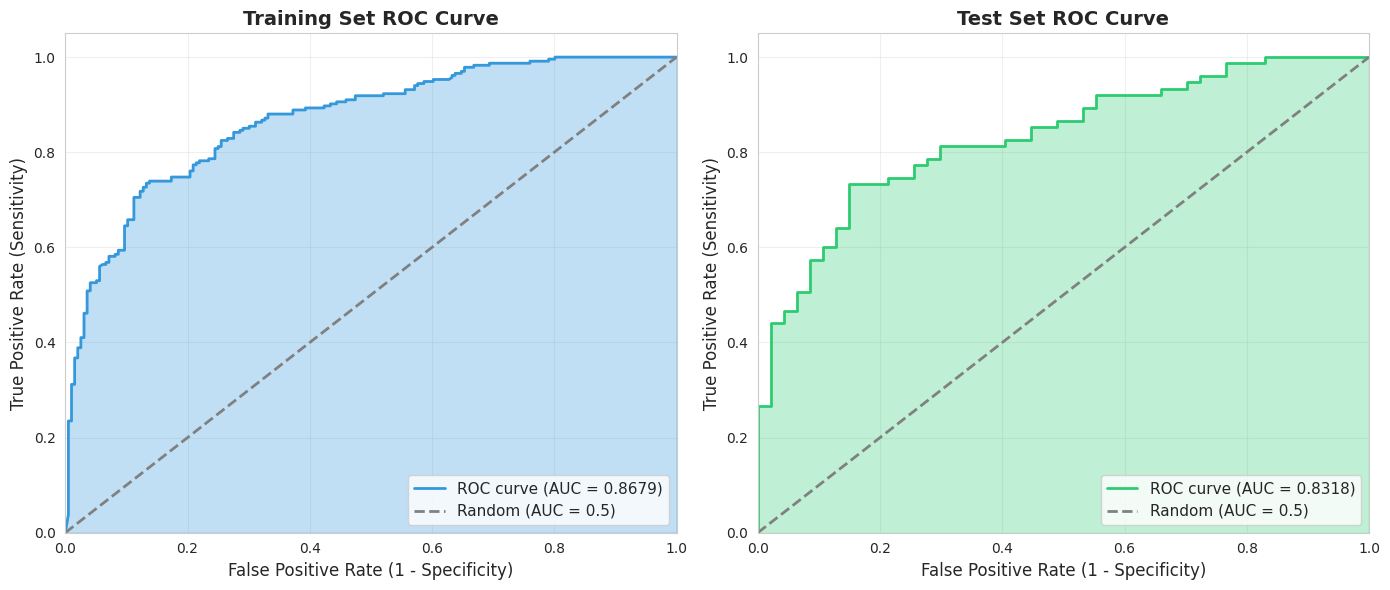

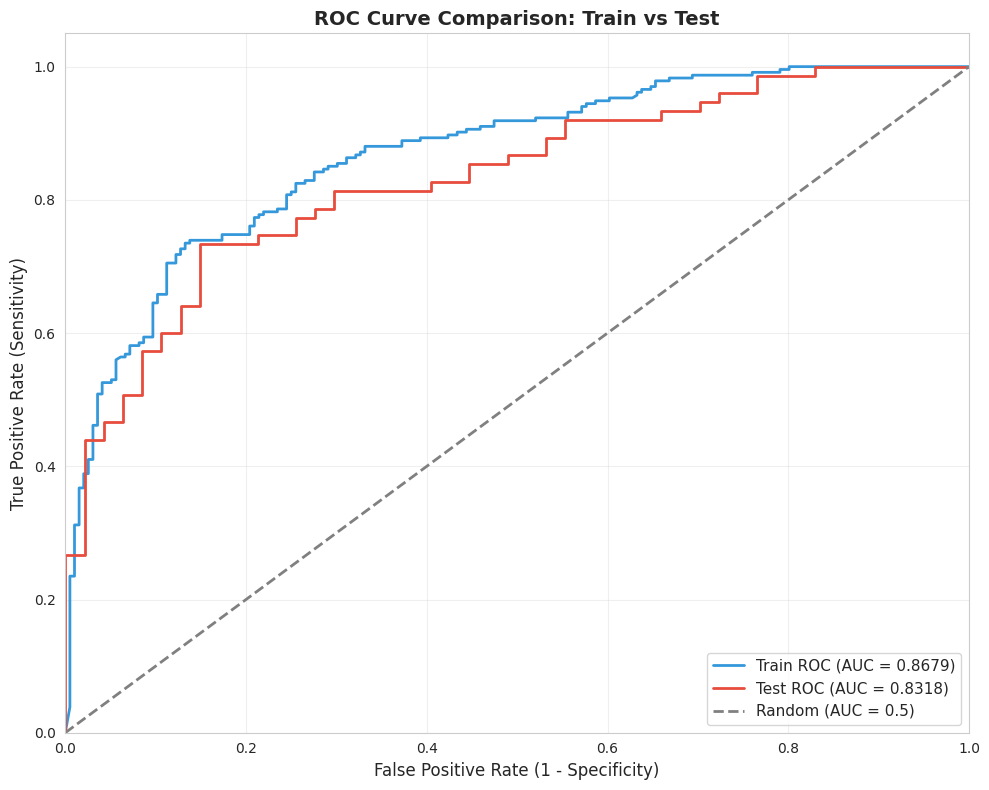


✓ ROC curves saved to: /content/results

AUC Summary:
  Training AUC: 0.8679
  Test AUC:     0.8318
  Gap:          0.0361


In [23]:
# Plot ROC Curves for Train and Test Sets
from sklearn.metrics import roc_curve, auc

print("\n" + "="*70)
print("ROC CURVE ANALYSIS")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training ROC Curve
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, train_probabilities)
roc_auc_train = auc(fpr_train, tpr_train)

axes[0].plot(fpr_train, tpr_train, color='#3498db', lw=2,
             label=f'ROC curve (AUC = {roc_auc_train:.4f})')
axes[0].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random (AUC = 0.5)')
axes[0].fill_between(fpr_train, tpr_train, alpha=0.3, color='#3498db')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[0].set_title('Training Set ROC Curve', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=11)
axes[0].grid(True, alpha=0.3)

# Test ROC Curve
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, test_probabilities)
roc_auc_test = auc(fpr_test, tpr_test)

axes[1].plot(fpr_test, tpr_test, color='#2ecc71', lw=2,
             label=f'ROC curve (AUC = {roc_auc_test:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random (AUC = 0.5)')
axes[1].fill_between(fpr_test, tpr_test, alpha=0.3, color='#2ecc71')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
axes[1].set_title('Test Set ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Combined ROC Curve for comparison
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr_train, tpr_train, color='#3498db', lw=2,
        label=f'Train ROC (AUC = {roc_auc_train:.4f})')
ax.plot(fpr_test, tpr_test, color='#e74c3c', lw=2,
        label=f'Test ROC (AUC = {roc_auc_test:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random (AUC = 0.5)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curve Comparison: Train vs Test', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curve_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ ROC curves saved to: {OUTPUT_DIR}")
print(f"\nAUC Summary:")
print(f"  Training AUC: {roc_auc_train:.4f}")
print(f"  Test AUC:     {roc_auc_test:.4f}")
print(f"  Gap:          {roc_auc_train - roc_auc_test:.4f}")

In [22]:
# Test on files from test_text_model folder (using selected features)
test_model_dir = BASE_DIR / 'test_text_model'
test_model_files = list(test_model_dir.glob('*.cha'))

print(f"\n{'='*70}")
print("TESTING ON test_text_model FOLDER")
print(f"{'='*70}")
print(f"Found {len(test_model_files)} test files\n")

test_results = []

for file_path in test_model_files:
    try:
        # Parse file
        parsed_data = parser.parse_file(str(file_path))
        features = extractor.extract_all_features(parsed_data)

        # Create feature vector with all features, then select
        feature_vector = pd.DataFrame([features])[feature_cols]
        feature_vector = feature_vector.replace([np.inf, -np.inf], np.nan).fillna(0)
        feature_vector_selected = selector.transform(feature_vector)
        feature_vector_sel = pd.DataFrame(feature_vector_selected, columns=feature_cols_selected)

        # Predict
        prediction, probability = classifier.predict(feature_vector_sel)

        test_results.append({
            'filename': file_path.name,
            'subject_id': parsed_data.get('subject_id', 'N/A'),
            'predicted_class': 'Dementia' if prediction[0] == 1 else 'Control',
            'dementia_probability': probability[0],
            'control_probability': 1 - probability[0],
            'word_count': features.get('word_count', 0),
            'total_disfluencies': features.get('total_disfluencies', 0)
        })

    except Exception as e:
        print(f"Error processing {file_path.name}: {e}")

# Create results DataFrame
test_results_df = pd.DataFrame(test_results)

# Sort by dementia probability (highest first)
test_results_df = test_results_df.sort_values('dementia_probability', ascending=False)

print("\nTest Results (sorted by Dementia probability):")
print("="*70)
display(test_results_df)

# Summary statistics
n_dementia = sum(test_results_df['predicted_class'] == 'Dementia')
n_control = sum(test_results_df['predicted_class'] == 'Control')

print(f"\n{'='*70}")
print("PREDICTION SUMMARY")
print(f"{'='*70}")
print(f"Total files tested: {len(test_results_df)}")
print(f"Predicted as Dementia: {n_dementia} ({n_dementia/len(test_results_df)*100:.1f}%)")
print(f"Predicted as Control: {n_control} ({n_control/len(test_results_df)*100:.1f}%)")
print(f"\nAverage Dementia Probability: {test_results_df['dementia_probability'].mean():.2%}")
print(f"Average Control Probability: {test_results_df['control_probability'].mean():.2%}")

# Save results
test_results_path = OUTPUT_DIR / 'test_text_model_predictions.csv'
test_results_df.to_csv(test_results_path, index=False)
print(f"\n✓ Test results saved to: {test_results_path}")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of predictions
prediction_counts = test_results_df['predicted_class'].value_counts()
colors = ['#e74c3c' if idx == 'Dementia' else '#2ecc71' for idx in prediction_counts.index]
axes[0].bar(prediction_counts.index, prediction_counts.values, color=colors)
axes[0].set_xlabel('Predicted Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Predictions on Test Files', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Probability distribution
axes[1].hist(test_results_df['dementia_probability'], bins=10, color='#3498db', edgecolor='black', alpha=0.7)
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
axes[1].set_xlabel('Dementia Probability', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Dementia Probabilities', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'test_text_model_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to: test_text_model_results.png")


TESTING ON test_text_model FOLDER
Found 0 test files



KeyError: 'dementia_probability'

---
## Summary

### ✅ Completed Tasks:
1. ✓ Environment setup and dependency installation
2. ✓ All core classes embedded (CHAFileParser, FeatureExtractor, AlzheimerClassifier)
3. ✓ Dataset loading and exploratory data analysis  
4. ✓ Model training with GroupKFold cross-validation
5. ✓ Performance evaluation and feature importance analysis
6. ✓ Model saving for production use
7. ✓ Inference on new data (single file and batch)

### 📊 Key Results:
- **Model Performance**: Check the cross-validation results above
- **Top Features**: Review the feature importance analysis
- **Saved Outputs**: All results are in the `results/` directory

### 📁 Output Files:
- `trained_model.pkl` - Trained classifier for inference
- `feature_importance.csv` - Feature rankings
- `training_predictions.csv` - Full dataset predictions  
- `classification_report.txt` - Detailed metrics
- Visualization plots (PNG files)

### 🚀 Next Steps:
- Use the saved model for production inference
- Experiment with different tasks (fluency, recall, sentence)
- Try ensemble methods combining multiple tasks
- Fine-tune hyperparameters for better performance

**This notebook is completely self-contained - share it with anyone and it will run independently!**